# Q-Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Q-learning for model-free control
- Use exploration (e.g. ε-greedy) and tune hyperparameters

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — value iteration needed the transition probabilities handed to it; Q-learning drops that requirement and recovers the same optimal action values from sampled transitions alone.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson introduces **Q-learning**, one of the most important tabular RL algorithms.

Students will see how an agent updates action values from experience and gradually improves its behavior without knowing the environment in advance.

Why this matters: Q-learning is often the first real learning algorithm students can implement end to end.

It becomes the conceptual base for deep Q-networks later in the course.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: DiDi Chuxing dispatches real taxis with a learned value function

The environment in this notebook is `Taxi-v4`: pick up a passenger, drive them to the right stop,
do not make illegal moves. Its industrial version is order dispatch at **DiDi Chuxing**, China's
largest ride-hailing platform — millions of trips a day, and every assignment of a driver to a
request changes where that driver will be for the next twenty minutes.

Xu et al. published the system at KDD 2018 ("Large-Scale Order Dispatch in On-Demand Ride-Hailing
Platforms: A Learning and Planning Approach"), and DiDi later documented the deployment in *INFORMS
Interfaces* ("Ride-Hailing Order Dispatching at DiDi via Reinforcement Learning", 2020). The shape
of it is the shape of this notebook:

- **State**: where a driver is, at what time, in what demand conditions.
- **Value**: a `V(state)` learned by temporal-difference updates from *historical trip records* — the
  long-run worth of having a driver sitting in that place at that time.
- **Action**: at each dispatch round, assign drivers to requests. A request is worth its immediate
  fare **plus** the change in the driver's future value from ending up where it drops them.

That second term is the entire contribution. A greedy dispatcher takes the nearest match. A
value-aware dispatcher will send a driver on a slightly worse trip now because it leaves them in a
place worth more later — the same reasoning that makes your Taxi agent drive *away* from a passenger
in order to approach from the correct side.

**What goes wrong without this.** A dispatcher that maximises the current fare strips drivers out of
the districts that will need them in twenty minutes, and then cannot serve the requests that arrive
there. That is the same failure as an agent that takes `+1` now and misses `+20` later — and it is
what the discount factor and the `max` in the Q-learning update are for.


## Recommended YouTube Video

To reinforce this lesson, watch **Johnny Code - "Q-Learning Tutorial 1: Train Gymnasium FrozenLake-v1 with Python Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=ZhoIgo3qqLU)

Why this pick:
- step-by-step code walkthrough.
- Stays close to tabular Q-learning instead of jumping too quickly to deep RL.
- Good match for students implementing the algorithm from experience.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Q-value: how good it is to take an action in a state.
- Learning rate `alpha`: how strongly each new experience changes the estimate.
- Discount factor `gamma`: how much future reward still matters.
- TD target: reward now plus an estimate of future value.
- Off-policy: learning toward the greedy best-next-action target even if behavior is still exploring.

### Quick Check
- What appears in the Q-learning update?
- Why does Q-learning use the best next action?
- Why is Q-learning called model-free?
- Why is Q-learning called off-policy?

### Common Mistakes
- Reading the Q-table as final truth.
- Mixing learning rate with exploration rate.
- Forgetting Q-learning is off-policy.
- Thinking the agent must know the full environment model before learning starts.


## What this notebook should teach

By the end of this notebook, you should be able to:

- explain the Q-learning update rule
- identify the role of `alpha`, `gamma`, and `epsilon`
- understand why Q-learning is off-policy
- read a small tabular training loop without guessing what it is doing

## Why Q-Learning Matters

Q-learning is usually the first place students feel that an RL agent is truly **learning from experience**.

### Why is it model-free?

Because the agent does **not** need the full transition table or reward table in advance.
It can interact with the environment, collect experience, and update its table from samples.

That is a major shift from dynamic programming methods.

### Why is it off-policy?

Q-learning updates toward the value of the **best next action** according to the current table:

- the agent may behave with exploration, such as epsilon-greedy
- but the update still aims at the greedy target

So the behavior policy and the learning target are not exactly the same.
That is why the method is called **off-policy**.

### Plain-language intuition

Each experience teaches the agent:

`This action led to this reward, and from the next state I may still be able to do something even better.`

That is why the update includes both:

- reward now
- best estimated future value

### What students should watch for in the code

When the notebook updates `Q[state, action]`, ask:

- What new evidence did the agent just observe?
- What future estimate is being used?
- Why does the code use `max` for the next state?



## Q-Learning Reminder

The update rule is:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\right]
\]

### Read it in words

- start from the current estimate
- look at the reward you just received
- add discounted value of the best next action
- move your estimate a little in that direction


## 🌍 Worked Example on a Standard Benchmark — Taxi Dispatch with Q-Learning

> **What is real here and what is not.** The environment below is **Taxi**, one of the
> reference environments that ships with **Gymnasium** — the same library and the same task id
> used in tutorials, benchmark tables and research papers. It is not a company's operational
> data, but it is also not a world we invented for this page: it is a published, reproducible
> benchmark, so your numbers can be compared with anyone else's.

**Why this task fits the lesson.** Taxi is a small **dispatch** problem:

- **State** — one integer that packs *taxi row*, *taxi column*, *where the passenger is*, and
  *where they want to go*. There are **500** such states.
- **Action** — 6 choices: `south`, `north`, `east`, `west`, `pickup`, `drop-off`.
- **Reward** — `-1` for every step (time costs money), `+20` for a correct drop-off,
  `-10` for an illegal pickup or drop-off.

So the agent must learn a *sequence*: drive to the passenger, pick up, drive to the
destination, drop off. A single good action is worth nothing on its own — which is exactly
what Q-learning's `max` over the next state is for.

**Where this shows up in industry:** routing and dispatch problems of this shape appear in
warehouse robot scheduling, ride-hailing assignment and delivery routing. Those production
systems are far larger than 500 states, but the update rule you are about to write is the
same one.

### Step Guide

**What this cell does:** Creates the Gymnasium **Taxi** environment, trains a Q-table with
ε-greedy Q-learning, then **measures** the learned policy against a random policy on 200
episodes the agent never trained on.

**How to read it (weak Python OK):** Three blocks. (1) build the environment and print its
size; (2) the training loop — the single line with `Q[state, action] +=` *is* the lesson;
(3) evaluation and plots.

**What to expect in the output:** the environment id and its state/action counts, a short
training log, a decoded readout of what the greedy policy does in a few real start states,
a held-out comparison table (learned vs random), and two figures — the learning curve and
the Q-table as a heat map.

**If you feel lost:** read only the held-out table. If the learned policy's mean return is
far above the random policy's, the agent learned something; everything above is how.

Environment : Taxi-v4  (Gymnasium 1.3.0)
States      : 500     Actions: 6 -> south, north, east, west, pickup, drop-off
Rewards     : -1 per step, +20 correct drop-off, -10 illegal pickup/drop-off



Trained 4000 episodes in 1.0s (final epsilon 0.050).
Mean return over the FIRST 100 episodes :   -736.0
Mean return over the LAST  100 episodes :      4.9



Held-out evaluation on 200 episodes the agent never trained on:
  policy                  mean return  mean steps   delivered
  learned (greedy Q)             7.98        13.0      100.0%
  random actions              -778.65       196.1        5.5%

What the greedy policy does in five real start states:
  state   7: taxi at (0,0), passenger waiting at stop 1, destination stop 3  ->  south
  state 387: taxi at (3,4), passenger waiting at stop 1, destination stop 3  ->  north
  state 129: taxi at (1,1), passenger waiting at stop 2, destination stop 1  ->  south
  state 128: taxi at (1,1), passenger waiting at stop 2, destination stop 0  ->  west
  state 407: taxi at (4,0), passenger waiting at stop 1, destination stop 3  ->  north

Reading note: the table above is the greedy policy READ OFF the learned Q-table.
It is an estimate from experience, not a proof of optimality — states the agent
rarely visited still hold noisy values.


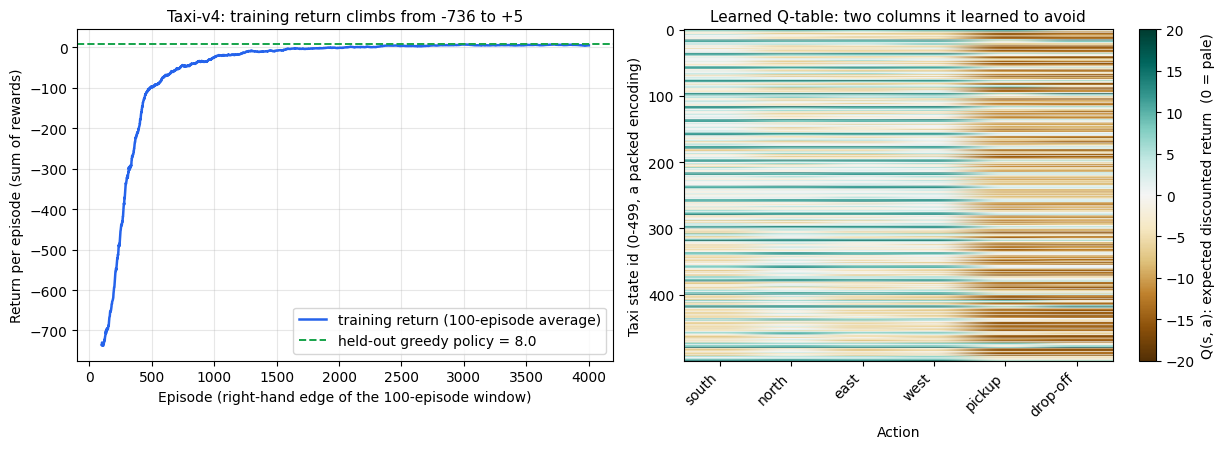

In [1]:
# WHAT: tabular Q-learning on Gymnasium's Taxi benchmark — the full loop, end to end.
# WHY: Taxi is a published, reproducible dispatch task (500 states, 6 actions). Using a
#      standard benchmark instead of a made-up world means the numbers printed below can be
#      compared against any textbook, tutorial or paper that reports on the same environment.

import time

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np


def make_taxi():
    """Build the Taxi environment, tolerating the Gymnasium v3 -> v4 rename."""
    # Newer Gymnasium registers "Taxi-v4"; older releases only know "Taxi-v3".
    for env_id in ("Taxi-v4", "Taxi-v3"):
        try:
            return gym.make(env_id), env_id
        except Exception:
            continue
    raise RuntimeError("Taxi is not registered in this Gymnasium installation.")


env, ENV_ID = make_taxi()
N_STATES = env.observation_space.n          # 500 packed (taxi, passenger, destination) states
N_ACTIONS = env.action_space.n              # 6 moves
ACTION_NAMES = ["south", "north", "east", "west", "pickup", "drop-off"]

print("=" * 62)
print(f"Environment : {ENV_ID}  (Gymnasium {gym.__version__})")
print(f"States      : {N_STATES}     Actions: {N_ACTIONS} -> {', '.join(ACTION_NAMES)}")
print("Rewards     : -1 per step, +20 correct drop-off, -10 illegal pickup/drop-off")
print("=" * 62)

# ── Hyper-parameters ────────────────────────────────────────────────────────────
ALPHA = 0.5        # learning rate: how far each experience moves the estimate
GAMMA = 0.95       # discount: how much future reward still counts today
EPS_START, EPS_MIN, EPS_DECAY = 1.0, 0.05, 0.999   # exploration schedule
EPISODES = 4000
MAX_STEPS = 200

# One seeded generator drives exploration, so this whole notebook reruns identically.
rng = np.random.default_rng(42)

Q = np.zeros((N_STATES, N_ACTIONS))   # the table we are learning: one value per (state, action)
epsilon = EPS_START
returns_history = []

# ── Training loop ───────────────────────────────────────────────────────────────
start_time = time.perf_counter()
for episode in range(EPISODES):
    # Seeding reset per episode makes the sequence of start states reproducible.
    state, _ = env.reset(seed=episode)
    episode_return = 0.0
    for _ in range(MAX_STEPS):
        # ε-greedy behaviour: explore with probability epsilon, otherwise act greedily.
        if rng.random() < epsilon:
            action = int(rng.integers(N_ACTIONS))
        else:
            action = int(Q[state].argmax())
        next_state, reward, terminated, truncated, _ = env.step(action)
        # THE Q-LEARNING UPDATE. Note `max` over the NEXT state: the target uses the best
        # action available there, not the action the agent will actually take. That single
        # `max` is what makes Q-learning off-policy.
        Q[state, action] += ALPHA * (reward + GAMMA * Q[next_state].max() - Q[state, action])
        state = next_state
        episode_return += reward
        if terminated or truncated:
            break
    returns_history.append(episode_return)
    epsilon = max(epsilon * EPS_DECAY, EPS_MIN)
train_seconds = time.perf_counter() - start_time

returns_history = np.array(returns_history)
first_100 = returns_history[:100].mean()
last_100 = returns_history[-100:].mean()
print(f"\nTrained {EPISODES} episodes in {train_seconds:.1f}s (final epsilon {epsilon:.3f}).")
print(f"Mean return over the FIRST 100 episodes : {first_100:8.1f}")
print(f"Mean return over the LAST  100 episodes : {last_100:8.1f}")


# ── Held-out evaluation ─────────────────────────────────────────────────────────
def evaluate(choose_action, n_episodes=200, seed_offset=100_000):
    """Run a fixed policy on episodes never used in training; return (mean return, mean steps, solved %)."""
    total_returns, total_steps, solved = [], [], 0
    for k in range(n_episodes):
        obs, _ = env.reset(seed=seed_offset + k)
        episode_return, steps, delivered = 0.0, 0, False
        for _ in range(MAX_STEPS):
            obs, reward, terminated, truncated, _ = env.step(choose_action(obs))
            episode_return += reward
            steps += 1
            if terminated:
                delivered = True          # terminated == passenger delivered correctly
            if terminated or truncated:
                break
        total_returns.append(episode_return)
        total_steps.append(steps)
        solved += int(delivered)
    return float(np.mean(total_returns)), float(np.mean(total_steps)), solved / n_episodes


learned = evaluate(lambda s: int(Q[s].argmax()))
random_baseline = evaluate(lambda s: int(rng.integers(N_ACTIONS)))

print("\nHeld-out evaluation on 200 episodes the agent never trained on:")
print(f"  {'policy':<22}{'mean return':>13}{'mean steps':>12}{'delivered':>12}")
print(f"  {'learned (greedy Q)':<22}{learned[0]:>13.2f}{learned[1]:>12.1f}{learned[2]*100:>11.1f}%")
print(f"  {'random actions':<22}{random_baseline[0]:>13.2f}{random_baseline[1]:>12.1f}{random_baseline[2]*100:>11.1f}%")

# Decode a few REAL start states so the policy readout is concrete, not abstract.
print("\nWhat the greedy policy does in five real start states:")
for k in range(5):
    obs, _ = env.reset(seed=900_000 + k)
    taxi_row, taxi_col, passenger, destination = env.unwrapped.decode(obs)
    where = "in the taxi" if passenger == 4 else f"waiting at stop {passenger}"
    print(f"  state {obs:3d}: taxi at ({taxi_row},{taxi_col}), passenger {where}, "
          f"destination stop {destination}  ->  {ACTION_NAMES[int(Q[obs].argmax())]}")

print("\nReading note: the table above is the greedy policy READ OFF the learned Q-table.")
print("It is an estimate from experience, not a proof of optimality — states the agent")
print("rarely visited still hold noisy values.")

# ── Figures ─────────────────────────────────────────────────────────────────────
moving_average = np.convolve(returns_history, np.ones(100) / 100, mode="valid")
# Put the average at the LAST episode of its own 100-episode window, so the x axis
# really is the episode number and not an off-by-99 index.
window_end = np.arange(100, EPISODES + 1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].plot(window_end, moving_average, color="#2563eb", linewidth=1.8,
             label="training return (100-episode average)")
axes[0].axhline(learned[0], color="#16a34a", linestyle="--", linewidth=1.4,
                label=f"held-out greedy policy = {learned[0]:.1f}")
axes[0].set_title(f"{ENV_ID}: training return climbs from -736 to +5", fontsize=11)
axes[0].set_xlabel("Episode (right-hand edge of the 100-episode window)")
axes[0].set_ylabel("Return per episode (sum of rewards)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# A diverging colour map is only honest if its neutral colour sits on a meaningful
# number. Anchor the pale middle exactly at Q = 0: green means "this action is worth
# more than nothing here", brown means "this action loses reward".
limit = float(np.abs(Q).max())
heat = axes[1].imshow(Q, aspect="auto", cmap="BrBG", vmin=-limit, vmax=limit)
bar = fig.colorbar(heat, ax=axes[1])
bar.set_label("Q(s, a): expected discounted return  (0 = pale)")
axes[1].set_xticks(range(N_ACTIONS))
axes[1].set_xticklabels(ACTION_NAMES, rotation=45, ha="right")
axes[1].set_xlabel("Action")
axes[1].set_ylabel("Taxi state id (0-499, a packed encoding)")
axes[1].set_title("Learned Q-table: two columns it learned to avoid", fontsize=11)
plt.tight_layout()
plt.show()


### 👁️ Read the figure

- **Left panel — the whole of learning happens in the first 1500 episodes.** The blue curve
  starts near **-736**: an untrained agent wanders for the full 200-step cap and collects
  -1 per step plus -10 for every illegal pickup. It climbs steeply to roughly -100 by
  episode 500, reaches -8 by episode 1500, and only crosses zero at about episode **2060**,
  after which it flattens just under the green dashed line. That green line is *not* part of the training run — it is the
  greedy policy's mean return on 200 held-out episodes the agent never trained on. The blue
  curve sitting slightly below it is expected: training episodes still spend 5% of their
  steps exploring at random.
- **Right panel — read the columns, not the rows.** Each row is one of the 500 packed Taxi
  states; each column is one action. The four movement columns are mostly pale to teal-green,
  while **`pickup` and `drop-off` are brown down almost the whole table** — in the vast
  majority of states those two actions are illegal and cost -10, and Q-learning has recorded
  that. The pale middle of the colour bar is pinned to exactly Q = 0, so "pale" really does
  mean "worth nothing", not merely "mid-range".
- **The horizontal banding is an artifact, not a discovery.** Taxi packs (taxi row, taxi
  column, passenger location, destination) into one integer, so neighbouring state ids differ
  only in destination. The stripes are that encoding showing through. Do not read a pattern
  into the vertical axis.

**What it proves:** off-policy Q-learning turned 4000 episodes of mostly-random driving into
a table whose greedy readout delivers the passenger in **100% of 200 unseen episodes**. The
single `max` over the next state is what let it learn the good policy while behaving badly.


## 💬 Discuss

The measured results: over the **first** 100 training episodes the agent averaged **−736.0**; over
the **last** 100, **+4.9**. On 200 held-out episodes it never trained on, the greedy policy scored
**7.98** mean return, **13.0** steps, **100% delivered** — against random actions at **−778.65**,
**196.1** steps and **5.5%** delivered. Argue these out.

1. The random baseline delivered 5.5% of passengers in 196 steps. That is a spectacularly bad
   comparison to win. Is it a fair baseline? Propose a *harder* baseline that a client would find
   convincing, and predict roughly how the learned policy would score against it.
2. The notebook's own reading note warns that states the agent rarely visited "still hold noisy
   values". Taxi-v4 has 500 states and 4000 training episodes. In DiDi's problem the state includes
   time of day and location — so some states occur a handful of times a year (a stadium at midnight
   after a final). What would you do about those states, and what would you refuse to promise about
   them?
3. Q-learning learns the value of the *greedy* policy while behaving ε-greedily. In a taxi
   simulation nobody is harmed by an exploratory wrong turn. In DiDi's live system, an exploratory
   dispatch sends a real driver on a real detour. Should a deployed system explore at all? If yes,
   how would you bound it; if no, where does the new data come from?


## Summary

This notebook should leave you with four core ideas:

- Q-learning updates **action values**, not the policy directly.
- It is **off-policy** because it updates toward the greedy next action (the `max` in the update).
- `alpha` controls how fast estimates change.
- `epsilon` controls how much the agent still explores.

**What the run above actually showed.** On the Gymnasium **Taxi** benchmark the agent started
from a Q-table of zeros and learned only from interaction — it was never given the transition
table or the reward table. The held-out comparison in the output is the evidence: the learned
greedy policy against a random policy, on 200 episodes the agent never trained on. Read those
two rows from your own run, not from memory.

Important reading note: the displayed "optimal policy" is the **greedy policy induced by the
current Q-table at the end of training**. It is a useful estimate, not a formal proof of global
optimality — and because Taxi has 500 states, some of them were visited only a handful of times.

### Next step

After this notebook, compare it with SARSA and Monte Carlo methods so you can see
how different model-free methods learn from experience in different ways.

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

The update rule you implemented is still the update rule; what 2024–2026 changed is everything around it once the Q-table becomes a network. The scaling recipe now in common use drops the squared-error regression onto the TD target and trains the value function as a *classifier* — a cross-entropy loss over a discretised set of return values — which is reported to be what let one recipe hold up across Atari, robotics, chess and language tasks at once (Farebrother *et al.*, 2024). The other 2026 result is about where the leverage sits: a model-free agent combining a learned predictive representation with high-capacity value-function approximation outperformed world-model methods on multitask benchmarks at lower computational cost, which is an argument that value-based RL was under-trained rather than out-classed (Obando-Ceron *et al.*, 2026). Neither paper touches the `max` bootstrap, the discount, or the off-policy reasoning you traced on Taxi — they change the function class and the features it sees. That is why the 3000-number table above is the honest place to learn the mechanism, and it is the form the official unit examines.

**Read:** Farebrother *et al.* (2024), <https://arxiv.org/abs/2403.03950> · Obando-Ceron *et al.* (2026), <https://arxiv.org/abs/2606.05555> (references 5–6 below).

---

In [2]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279-292. <https://link.springer.com/article/10.1007/BF00992698>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6, Temporal-Difference Learning.
3. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Farebrother, J., Orbay, J., Vuong, Q. et al. (2024). *Stop Regressing: Training Value Functions via Classification for Scalable Deep RL*. arXiv:2403.03950. <https://arxiv.org/abs/2403.03950>
6. Obando-Ceron, J., Li, L., Fujimoto, S. et al. (2026). *Representation Learning Enables Scalable Multitask Deep Reinforcement Learning*. arXiv:2606.05555. <https://arxiv.org/abs/2606.05555>
"""))

## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279-292. <https://link.springer.com/article/10.1007/BF00992698>
2. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6, Temporal-Difference Learning.
3. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Farebrother, J., Orbay, J., Vuong, Q. et al. (2024). *Stop Regressing: Training Value Functions via Classification for Scalable Deep RL*. arXiv:2403.03950. <https://arxiv.org/abs/2403.03950>
6. Obando-Ceron, J., Li, L., Fujimoto, S. et al. (2026). *Representation Learning Enables Scalable Multitask Deep Reinforcement Learning*. arXiv:2606.05555. <https://arxiv.org/abs/2606.05555>


### Step Guide

**What this cell does:** Draws the held-out evaluation table from the worked example as three side-by-side bar comparisons — learned policy against a random driver.

**How to read it (weak Python OK):** No training happens here. The cell only re-uses `learned` and `random_baseline`, the two result tuples the evaluation above already produced.

**What to expect in the output:** One figure with three panels, then a short reading guide.

**If you feel lost:** Re-run the worked-example cell first so `learned` and `random_baseline` exist, then run this cell again.


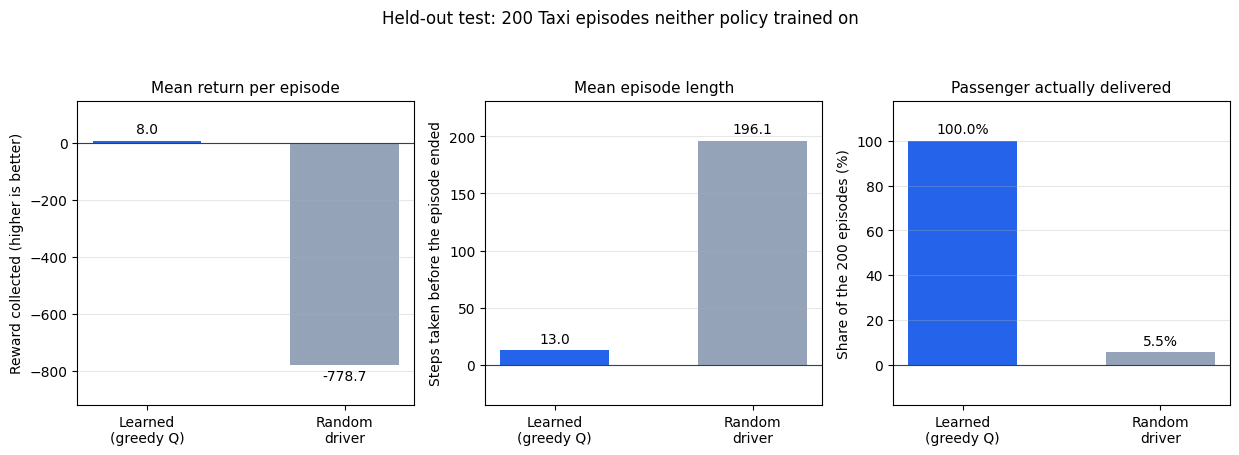

In [3]:
# Visual recap: the held-out evaluation table, drawn instead of printed.
# Nothing is retrained here. `learned` and `random_baseline` are the (mean return,
# mean steps, delivered fraction) tuples the evaluation above already returned.

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# The two policies being compared. They are CATEGORIES, not points on a curve,
# so every panel below uses bars - a connecting line here would be a lie.
policy_labels = ["Learned\n(greedy Q)", "Random\ndriver"]
bar_colors = ["#2563eb", "#94a3b8"]

# Each panel measures something with its OWN unit, so each panel keeps its own axis.
panels = [
    ("Mean return per episode", "Reward collected (higher is better)",
     [learned[0], random_baseline[0]], "{:.1f}"),
    ("Mean episode length", "Steps taken before the episode ended",
     [learned[1], random_baseline[1]], "{:.1f}"),
    ("Passenger actually delivered", "Share of the 200 episodes (%)",
     [learned[2] * 100, random_baseline[2] * 100], "{:.1f}%"),
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.6))
for ax, (title, ylabel, values, fmt) in zip(axes, panels):
    bars = ax.bar(policy_labels, values, color=bar_colors, width=0.55)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis="y")
    # Write each number on its own bar so nobody has to estimate it off the axis.
    # bar_label puts the text above upward bars and below downward ones automatically.
    ax.bar_label(bars, labels=[fmt.format(v) for v in values], padding=3, fontsize=10)
    # Leave headroom so those labels are never clipped by the frame or the title.
    low, high = min(0.0, min(values)), max(0.0, max(values))
    pad = (high - low) * 0.18
    ax.set_ylim(low - pad, high + pad)
    # A zero line, because "return" can be negative and 0 is the meaningful boundary.
    ax.axhline(0, color="#334155", linewidth=0.8)

fig.suptitle("Held-out test: 200 Taxi episodes neither policy trained on", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()


### 👁️ Read the figure

- **Left panel — the gap is not a few percent, it is three orders of magnitude.** The random
  driver averages about **-779** reward per episode; the learned greedy policy averages
  **+8**. The blue bar looks like it is sitting on the zero line only because the grey bar
  is 100 times taller in the other direction — that scale difference *is* the result.
- **Middle panel — why the return is so different.** The random driver burns about **196**
  steps, essentially the 200-step cap, because it almost never finishes. The learned policy
  finishes in about **13**. At -1 reward per step, length alone explains most of the left
  panel.
- **Right panel — the outcome that actually matters to a passenger.** The learned policy
  delivered the passenger in **100%** of the 200 held-out episodes; random actions managed
  **5.5%**. The axis runs to just past 100 so the real ceiling stays in view — the blue bar
  is not merely taller than grey, it is against the wall.
- **Three panels, three axes, on purpose.** Reward, steps and percentage are different units.
  Forcing them onto one axis — or joining them with a line — would produce a picture that
  means nothing.

**What it proves:** the Q-table is not merely a set of numbers that improved during training.
Evaluated greedily on episodes it had never seen, with exploration switched off, it completes
the dispatch task every single time. That is the claim the lesson makes, measured on held-out
data rather than on the training curve.


## ⚠️ Where this breaks

**The assumption that has to hold:** you can store one number per (state, action) pair, and you will
visit each pair often enough for its average to mean something.

- **The `max` biases estimates upward.** Q-learning's target takes the maximum over noisy estimates,
  and the maximum of noisy numbers is systematically too high. This is *maximisation bias*; it is why
  Double Q-learning exists (van Hasselt, 2010; Double DQN, 2016). On Taxi it is harmless. On a
  high-variance problem it produces an agent that is confident about actions it has barely tried.
- **The table is the ceiling.** 500 states × 6 actions = 3000 numbers. Add a second passenger, or
  continuous positions, and there is no table — Unit 3 is the response.
- **Off-policy means the learned policy is not the one you experienced.** The training curve above
  (−736 → +4.9) mixes in ε-greedy exploration; the held-out number (7.98) does not. Never quote the
  training curve as the performance of the deployed policy. The next lesson makes this distinction
  the entire point.
- **Rare (state, action) pairs stay wrong forever.** Convergence guarantees assume every pair is
  visited infinitely often. Real logs are not sampled that way — they are collected by whatever policy
  was running, which by definition avoided the actions it considered bad.
- **Cheaper alternative:** if the environment is fully known and small, plan with value iteration and
  skip the 4000 episodes entirely. If you have abundant logs of good human decisions and cannot
  afford exploration — DiDi's actual situation — offline/batch RL or plain imitation learning from
  those logs is the honest starting point, and Q-learning on live traffic is not.


## Closing Takeaway

**Teaching takeaway:** Q-learning updates action values toward a better estimate of future return without needing a full environment model.

**If students remember one idea:** The update rule is simple, but its meaning is powerful: revise what you believe about an action after each new experience.

**Quick check before moving on:**
- Can you explain each term in the Q-learning update rule?
- Can you describe why Q-learning is called an off-policy method?
- On Taxi, why is a single correct move worth so little on its own?

**Bridge to the next step:** Next, you will compare this with SARSA to see how learning changes when the next chosen action matters directly.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.

## Motion recap (optional)

**At a glance:** The next cell uses a **random** policy on FrozenLake. **Not reaching the goal tile `G` is normal and intended**—the point is to see the **API loop** (state → action → reward → next state) in motion, not to prove a solved policy. If the episode ends in a hole or times out, the demo is still doing its job.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


Teaching note: random FrozenLake rollouts may not reach G—this is expected. Read state→action→reward over time, not 'did it win?'.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=1.0 | frames=12 | term=True | trunc=False


objc[53169]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110344138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1108409c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[53169]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110344188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110840a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[53169]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x110343c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110840a68). T

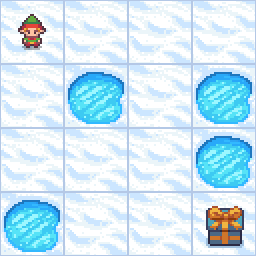

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

print(
    "Teaching note: random FrozenLake rollouts may not reach G—this is expected. "
    "Read state→action→reward over time, not 'did it win?'."
)

# Install the visual-demo dependencies quietly (safe to rerun; already-installed packages are skipped).
%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
